

---

##  Overview

In this assignment, you will build, train, and evaluate Convolutional Neural Networks (CNNs) using the **CIFAR-10** dataset — a well-known benchmark dataset containing **60,000 color images** across **10 classes** (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).

- **Image size:** 32×32 pixels, 3 channels (RGB)
- **Training set:** 50,000 images
- **Test set:** 10,000 images
- **Classes:** 10 balanced classes (6,000 images per class)

CIFAR-10 is ideal for this assignment: it is small enough to train on a CPU/free GPU (Google Colab), yet complex enough to make architectural choices meaningful.

---

##  Learning Objectives

By completing this assignment, you will be able to:
1. Understand and implement convolutional layers, pooling, and filters
2. Apply data augmentation to improve model generalization
3. Build and compare different CNN architectures
4. Evaluate models using appropriate metrics

---




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor, Normalize, Compose
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

#To save my models to be able to load them later in a separate runtime and compare them all
from google.colab import drive
drive.mount('/content/drive')

Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load the Dataset

Load the CIFAR-10 training and test sets using `torchvision.datasets.CIFAR10`.

Create DataLoaders with:
- `batch_size = 64`
- `shuffle=True` for train, `shuffle=False` for test

# 1. Data Exploration and Visualization

# Loading the dataset and inspecting its structure

In [ ]:
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

train_data = CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=ToTensor()
)#changed it to a tensor while we load it

val_data = CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=ToTensor()
)

batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,#so it doesnt overfit
    num_workers=4,#how many batches will work in parallel, if i want to assign all cpus to it can do os.cpu_count()
    pin_memory=True
)

#data loader shuffle is false by default
val_loader = DataLoader(
    val_data,
    batch_size=batch_size*2,#because keda keda size of the batch doesnt matter in delaying the processing speed cuz were just testing
    num_workers=4,
    pin_memory=True#makes data transfer from CPU memory to GPU memory faster
)

##Checking class balance

In [ ]:
from collections import Counter

#all labels from the training dataset
labels = train_data.targets  #list of numeric labels

#samples per class
class_counts = Counter(labels)#counter is like a loop that counts how many per class instead of doing an actual loop

for i, count in class_counts.items():
    print(f"{train_data.classes[i]}: {count} samples")

frog: 5000 samples
truck: 5000 samples
deer: 5000 samples
automobile: 5000 samples
bird: 5000 samples
horse: 5000 samples
ship: 5000 samples
cat: 5000 samples
dog: 5000 samples
airplane: 5000 samples


# Displaying the number of samples, classes and image shape (height × width × channels)

In [ ]:
#samples
print("Number of training samples:", len(train_data))
print("Number of validation/testing samples:", len(val_data))

#classes
print("Number of classes:", len(train_data.classes))# .classes is a built in attribute of the dataset object

#shape
image, label = train_data[0]  #first sample
print("Image shape (H x W x C):", image.shape[1], "x", image.shape[2], "x", image.shape[0])#usually Channels,Height,Width but to be nicer i reorganized

#class names (to put in array for displaying later)
print("Class names:", train_data.classes)

Number of training samples: 50000
Number of validation/testing samples: 10000
Number of classes: 10
Image shape (H x W x C): 32 x 32 x 3
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


#Visualizing the dataset

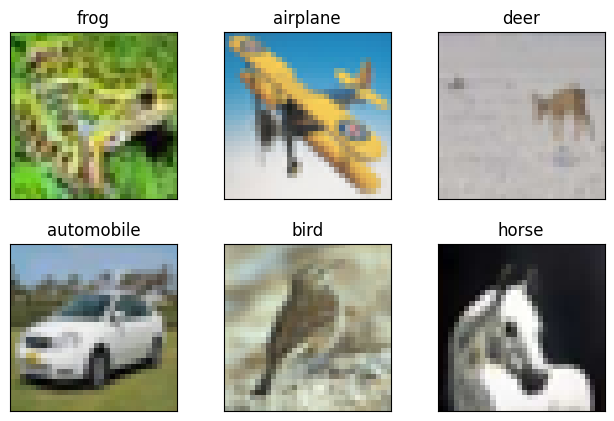

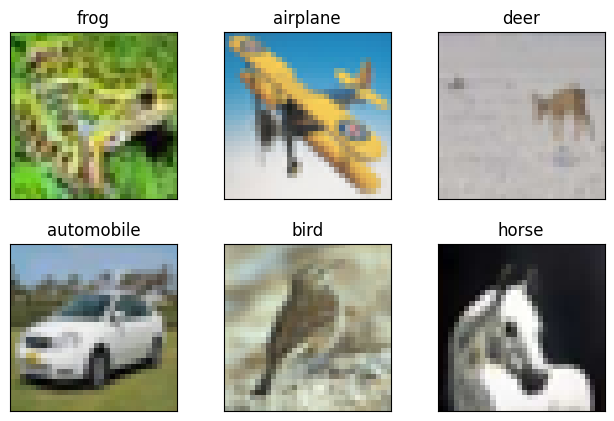

In [ ]:
example_data, example_targets = next(iter(train_loader))#iter() turns the dataloader into an iterator,next() takes the next item from the iterator
#returns the image and the target label

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']#just to label the pictures instead of having class [number] as the label


fig = plt.figure()
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.tight_layout()

    img = example_data[i].permute(1,2,0)   # convert (C,H,W) to (H,W,C) (channel, height,width) this is different than the MNIST bcs it was grayscale while CIFAR is RGB
    plt.imshow(img)#permute reorders the dimensions of the tensor bcs this is the default for CIFAR (0,1,2), (C,H,W) but matplot expects (H,W,C)

    plt.title(classes[example_targets[i]])
    plt.xticks([])
    plt.yticks([])

fig

#Brief description:
* image resolution: very low, images are very pixeled (its difficult for me personally to tell what the picture is)
* class balance: the classes are perfectly balanced 5000 images per class
* visual differences between classes:the objects are not always perfectly centered and some are not fully in frame like the cat(not fully in frame) vs the bird (fully in frame)

# 2. Data Preprocessing


# Normalizing the image pixel values

In [ ]:
#loading training data to compute mean and std
train_data_stats = CIFAR10(root='./data', train=True, download=True, transform=ToTensor())

#iterating and getting all images without their labels and putting them into a tensor of shape (N, C, H, W) where N is the number of images
all_train_images = torch.stack([img for img, _ in train_data_stats], dim=0)#dim=0 stacks images vertically along new axis

#mean and std per channel
mean = all_train_images.mean(dim=[0, 2, 3])#the dimension means over all images over height and width and ignores C
std = all_train_images.std(dim=[0, 2, 3])

print("Computed mean:", mean)
print("Computed std:", std)

#transform with normalization using computed mean/std
transform = Compose([#compose just lets us apply the transformation to all images together (output of 1 transform is input to the next)
    ToTensor(),#converting the images to tensors
    Normalize(mean=mean.tolist(), std=std.tolist())#converting the mean and std to lists bcs thats what the function expects
])

#reloading datasets with normalization
train_data = CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = CIFAR10(root='./data', train=False, download=True, transform=transform)#testing data

Computed mean: tensor([0.4914, 0.4822, 0.4465])
Computed std: tensor([0.2470, 0.2435, 0.2616])


# Splitting the dataset into training set,testing set and validation set


In [ ]:
train_size = 45000
val_size   = 5000
train_data, val_data = random_split(train_data, [train_size, val_size])


#we carried out this step again after the normalized data above and to have training validation and test sets after the split
batch_size = 64

train_loader = DataLoader(
    train_data,#from the split
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,#part of the training set we took as val from the split
    batch_size=batch_size*2,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,#from the data we normalized above, gonna be used in final model evaluation
    batch_size=batch_size*2,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Will not convert the labels into categorical format (one-hot encoding) since I will be using CrossEntropyLoss which expects integer class indices


# Brief explaination of why preprocessing is important:
* So training can converge faster, in this case with normalization it centers pixel values around 0 and scales them to similar ranges so that gradients can be balanced to prevent training from becoming unstable.
* Reduces computational load in this case where images are converted to tensors allows efficient batching in DataLoader



# Automatic Model Trainer

In [ ]:
class ModelTrainer():#stores train and val acc
  """The class automatically train our model
  """
  def fit(self, epochs, learning_rate, model, train_loader, val_loader,
          opt_func=torch.optim.SGD):#default optimizer as SGD

    """The function trains a model according to the hyperparameters:
    - epochs: the total number of epochs of training
    - learning_rate: the learning rate of our optimizer
    - model: the model to be trained
    - train_loader: the loader holding the training data
    - val_loader: the loader holding the validation data
    """
    history = []
    optimizer = opt_func(model.parameters(), learning_rate)

    for epoch in range(epochs):

      # Training
      model.train()
      batch_losses = []
      batch_accs   = []
      for batch in train_loader:#the data loader gives the data in batches 32 or 64 so it can work in parallel and be faster

        # Clear the parameter gradients
        optimizer.zero_grad()
        # perform the forward pass and compute the loss
        #loss = model.training_step(batch)
        training_output = model.training_step(batch)
        loss = training_output['training_loss'] #extracting the loss tensor from the dictionary
        acc  = training_output['training_acc']
        # perform the backward pass
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        batch_accs.append(acc.item())

      train_loss = sum(batch_losses) / len(batch_losses)
      train_acc  = sum(batch_accs)   / len(batch_accs)

      # Validation
      model.eval()
      result = self._evaluate(model, val_loader)
      model.epoch_end(epoch, result)
      history.append({
          'train_loss': train_loss,
          'train_acc':  train_acc,
          **result
      })

    return history

  def _evaluate(self, model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

# Accuracy and Plot history functions

In [ ]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

#plotting both train and val acc
def plot_history(history, model_name):
  train_losses = [x['train_loss'] for x in history]
  train_accs   = [x['train_acc']  for x in history]
  val_losses   = [x['val_loss']   for x in history]
  val_accs     = [x['val_acc']    for x in history]
  epochs       = range(1, len(history) + 1)

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Loss
  axes[0].plot(epochs, train_losses, '-o', label='Train Loss')
  axes[0].plot(epochs, val_losses,   '-s', label='Val Loss')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss')
  axes[0].set_title(f'{model_name} – Train vs Val Loss')
  axes[0].legend()
  axes[0].grid(True)

  # Accuracy
  axes[1].plot(epochs, train_accs, '-o', label='Train Accuracy')
  axes[1].plot(epochs, val_accs,   '-s', label='Val Accuracy')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Accuracy')
  axes[1].set_title(f'{model_name} – Train vs Val Accuracy')
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()

note: previously we used to define input_size and num_classes, input_size was for when we used FNN but now flatten happens within the network (so we dont have to do 32x32x3) and the model knows the number of outputs since its hardcoded in the last layer

# 3. CNN Models


---



* **Note:** I will use filter size 3x3 for all networks because its the most reasonable size (rather than 5x5 and 7x7) since the images are already tiny (32x32) and the smaller filter size will allow for better capturing of details such as curves and edges etc.

* For the sake of saving up my runtime I will stick to using 3x3 and will play around with the rest of the hyperparameters (number of convolution layers, pooling techniques,adding dropout/batch normalization)

* Since I already experimented with this data set but without using batchnorm or dropout, in the following models I will use them in all my models to improve the behavior more than that of the lab models (But I still have the lab models as a reference).


* Finally since I'm using F.cross_entropy which applied internal log_softmax I will not be adding softmax activation in the output layer because it would squash the probabilities more making training poor.

#CNN 1:
*   Depth: 2 layers
*   Width: 32 to 64
*   Pooling: MaxPool (kernel=2, stride=2)
*   Regularization: BatchNorm after each conv, Dropout(0.5) in FC
*   Fully connected: FC(128) to output(10)

BatchNorm stabilizes activations and makes training faster

Dropout(0.5) prevents the classifier from overfitting


In [ ]:
class CNN1(nn.Module):
    def __init__(self, accuracy_function):
        super().__init__()
        self.accuracy_function = accuracy_function

        # Create Convolutional Layers
        self.model = nn.Sequential(
            #Dimension: 32x32 to 16x16
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),          #normalises feature maps for faster and more stable training
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Dimension: 16x16 to 8x8
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),                   #the number inside is the number of neurons/ features and feature maps coming from the previous layer
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #NN itself
            nn.Flatten(),
            nn.Linear(8*8*64, 128),#FCC
            nn.ReLU(),
            nn.Dropout(p=0.5),           #randomly zeroing out 50% of neurons and reduces overfitting
            nn.Linear(128, 10)
        )
        #8*8*64=4096
        #128x4096 , every one of those 4,096 input values is connected to every one of the 128 neurons

    def forward(self, input_image):
        # Just run the input into the sequential model
        output = self.model(input_image)
        return output

    def training_step(self, batch):
        # Load batch
        images, labels = batch #again taking batches instead of all the images at once

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'training_loss': loss, 'training_acc': acc}

    def validation_step(self, batch):
        # Load batch
        images, labels = batch

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'val_loss': loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):

        # Combine losses and return mean value
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()

        # Combine accuracies and return mean value
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch: {} - Validation Loss: {:.4f}, Validation Accuracy: {:.4f}\
              ".format(epoch+1, result['val_loss'], result['val_acc']))


# CNN 2:
*   Depth: 3 layers
*   Width: 64 to 128 to 128
*   Pooling: MaxPool (kernel=2, stride=2)
*   Regularization: BatchNorm after each conv, Dropout(0.4) in FC
*   Fully connected: FC(256) to output(10)

lower Dropout(0.4) is used here because third pooling layer already reduces spatial dimensions which is technically also considered as regularization.


In [ ]:
class CNN2(nn.Module):
    def __init__(self, accuracy_function):
        super().__init__()
        self.accuracy_function = accuracy_function

        # Create Convolutional Layers
        self.model = nn.Sequential(
            #Dimension: 32x32 to 16x16
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),                                #batchnorm helps keep the values from getting to large to prevent unstable training
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Dimension: 16x16 to 8x8
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Dimension: 8x8 tp 4x4
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #NN itself
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(256, 10)
        )

    def forward(self, input_image):
        # Just run the input into the sequential model
        output = self.model(input_image)
        return output

    def training_step(self, batch):
        # Load batch
        images, labels = batch #again taking batches instead of all the images at once

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'training_loss': loss, 'training_acc': acc}

    def validation_step(self, batch):
        # Load batch
        images, labels = batch

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'val_loss': loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):

        # Combine losses and return mean value
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()

        # Combine accuracies and return mean value
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch: {} - Validation Loss: {:.4f}, Validation Accuracy: {:.4f}\
              ".format(epoch+1, result['val_loss'], result['val_acc']))


# CNN 3:
*   Depth: 4 layers in pairs
*   Width: 32 to 64 to 128 to 128
*   Pooling: MaxPool (kernel=2, stride=2) after each block
*   Regularization: BatchNorm after every conv, Dropout(0.5) in FC
*   Fully connected: FC(512) to FC(128) to output(10)

Pairing conv layers (like VGG) allows the network to learn better features at the same spatial scale before pooling. Dropout(0.5) at the beginning of the FC provides strong regularization to prevent overfitting early on.


note:VGG uses many small 3x3 convolution filters stacked on top of each other instead of using large filters.
This helps learn more complex patterns while staying simple.

In [ ]:
class CNN3(nn.Module):
    def __init__(self, accuracy_function):
        super().__init__()
        self.accuracy_function = accuracy_function

        self.model = nn.Sequential(
            #Dimension:32x32 to 16x16 (double convs and 1 pooling at the end)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Dimension:16x16 to 8x8 (double convs and 1 pooling at the end)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #NN itself
            nn.Flatten(),
            nn.Linear(128*8*8, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 10)

        )

    def forward(self, input_image):
        # Just run the input into the sequential model
        output = self.model(input_image)
        return output

    def training_step(self, batch):
        # Load batch
        images, labels = batch #again taking batches instead of all the images at once

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'training_loss': loss, 'training_acc': acc}

    def validation_step(self, batch):
        # Load batch
        images, labels = batch

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'val_loss': loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):

        # Combine losses and return mean value
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()

        # Combine accuracies and return mean value
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch: {} - Validation Loss: {:.4f}, Validation Accuracy: {:.4f}\
              ".format(epoch+1, result['val_loss'], result['val_acc']))


# CNN 4:
*   Depth: 5 layers (three parts: 2 layers then pool, 2 layers then pool, 1 layer then pool)
*   Width: 32 to 64 to 128 to 256
*   Pooling: MaxPool (kernel=2, stride=2)
*   Regularization: BatchNorm after every conv, Dropout(0.3) between FC layers, Dropout(0.5) before output
*   Fully connected: FC(256) to FC(128) to output(10)

The first two parts have two conv layers before pooling (like VGG) and the third part uses a single wider conv (256 filters) to capture more abstract features. Double dropout in the classifier strongly regularizes the larger fully connected part, starting with small dropout then increase it near the end.


In [ ]:
class CNN4(nn.Module):
    def __init__(self, accuracy_function):
        super().__init__()
        self.accuracy_function = accuracy_function

        self.model = nn.Sequential(
            #Dimension:32×32 to 16×16
            nn.Conv2d(in_channels=3,   out_channels=32,  kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32,  out_channels=64,  kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Dimension:16×16 to 8×8
            nn.Conv2d(in_channels=64,  out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Dimension: 8×8 to 4×4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #NN itself 256×4×4 = 4096
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),           # light dropout after first FC because were still early on and the mdeol is still learning. if we do heavy regularization now it will lose a lot of info and may underfit
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),           #strong regularization here because were near the end and the model is more likely to overfit and rely on specific neurons
            nn.Linear(128, 10)
        )

    def forward(self, input_image):
        # Just run the input into the sequential model
        output = self.model(input_image)
        return output

    def training_step(self, batch):
        # Load batch
        images, labels = batch #again taking batches instead of all the images at once

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'training_loss': loss, 'training_acc': acc}

    def validation_step(self, batch):
        # Load batch
        images, labels = batch

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'val_loss': loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):

        # Combine losses and return mean value
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()

        # Combine accuracies and return mean value
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch: {} - Validation Loss: {:.4f}, Validation Accuracy: {:.4f}\
              ".format(epoch+1, result['val_loss'], result['val_acc']))



was just trying with weight decay (resulted in 79%)

In [ ]:
class CNN4(nn.Module):
    def __init__(self, accuracy_function):
        super().__init__()
        self.accuracy_function = accuracy_function

        self.model = nn.Sequential(
            #Dimension:32×32 to 16×16
            nn.Conv2d(in_channels=3,   out_channels=32,  kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32,  out_channels=64,  kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Dimension:16×16 to 8×8
            nn.Conv2d(in_channels=64,  out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Dimension: 8×8 to 4×4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #NN itself 256×4×4 = 4096
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),           # light dropout after first FC because were still early on and the mdeol is still learning. if we do heavy regularization now it will lose a lot of info and may underfit
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),           #strong regularization here because were near the end and the model is more likely to overfit and rely on specific neurons
            nn.Linear(128, 10)
        )

    def forward(self, input_image):
        # Just run the input into the sequential model
        output = self.model(input_image)
        return output

    def training_step(self, batch):
        # Load batch
        images, labels = batch #again taking batches instead of all the images at once

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'training_loss': loss, 'training_acc': acc}

    def validation_step(self, batch):
        # Load batch
        images, labels = batch

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'val_loss': loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):

        # Combine losses and return mean value
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()

        # Combine accuracies and return mean value
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch: {} - Validation Loss: {:.4f}, Validation Accuracy: {:.4f}\
              ".format(epoch+1, result['val_loss'], result['val_acc']))


# 4.  Max Pooling vs Average Pooling

CNN 2 but with Avg Pooling

In [ ]:
class CNN2_avg(nn.Module):
    def __init__(self, accuracy_function):
        super().__init__()
        self.accuracy_function = accuracy_function

        # Create Convolutional Layers
        self.model = nn.Sequential(
            #Dimension: 32x32 to 16x16
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),                                #batchnorm helps keep the values from getting to large to prevent unstable training
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            #Dimension: 16x16 to 8x8
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            #Dimension: 8x8 tp 4x4
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            #NN itself
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(256, 10)
        )

    def forward(self, input_image):
        # Just run the input into the sequential model
        output = self.model(input_image)
        return output

    def training_step(self, batch):
        # Load batch
        images, labels = batch #again taking batches instead of all the images at once

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'training_loss': loss, 'training_acc': acc}

    def validation_step(self, batch):
        # Load batch
        images, labels = batch

        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        # Generate predictions
        output = self(images)

        # Calculate loss
        loss = F.cross_entropy(output, labels)

        # Calculate accuracy
        acc = self.accuracy_function(output, labels)

        return {'val_loss': loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):

        # Combine losses and return mean value
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()

        # Combine accuracies and return mean value
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch: {} - Validation Loss: {:.4f}, Validation Accuracy: {:.4f}\
              ".format(epoch+1, result['val_loss'], result['val_acc']))



## Evaluation function

In [ ]:
def evaluate_model(model, train_loader, test_loader, device):
    model.eval()

    def get_accuracy(loader):
        correct = 0
        total   = 0
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        return correct / total

    train_acc = get_accuracy(train_loader)
    test_acc  = get_accuracy(test_loader)
    return train_acc, test_acc

#5. Architecture Analysis (Model Explanation)


## Model 2:

Input: (batch, 3, 32, 32): 3 RGB channels, 32x32 image

To calculate the parameters: kernel height x kernel width x in_channels x out_channels, plus one bias per output channel

**Conv Layer 1**

Conv2d(in=3,out=64, kernel=3, padding=1)

Input shape: (batch, 3, 32, 32)

Spatial change: padding=1 so same image size 32x32 stays 32x32

Output shape: (batch, 64, 32, 32)

Parameters: (3 x 3 x 3 x 64) + 64 = 1,728 + 64 = 1,792

MaxPool2d(kernel=2, stride=2)

Input shape: (batch, 64, 32, 32)

Spatial change: halves dimensions so 32x32 becomes 16x16

Output shape: (batch, 64, 16, 16)

**Conv Layer 2**

Conv2d(in=64,out=128, kernel=3, padding=1)

Input shape: (batch, 64, 16, 16)

Spatial change: padding=1 so same image size 16x16 stays 16x16

Output shape: (batch, 128, 16, 16)

Parameters: (3 x 3 x 64 x 128) + 128 = 73,728 + 128 = 73,856

MaxPool2d(kernel=2, stride=2)

Input shape: (batch, 128, 16, 16)

Spatial change: halves dimensions so 16x16 becomes 8x8

Output shape: (batch, 128, 8, 8)



**Conv Layer 3**

Conv2d(in=128,out=128, kernel=3, padding=1)

Input shape: (batch, 128, 8, 8)

Spatial change: padding=1 so same image size 8x8 stays 8x8

Output shape: (batch, 128, 8, 8)

Parameters: (3 x 3 x 128 x 128) + 128 = 147,456 + 128 = 147,584

MaxPool2d(kernel=2, stride=2)

Input shape: (batch, 128, 8, 8)

Spatial change: halves dimensions so 8x8 becomes 4x4

Output shape: (batch, 128, 4, 4)



**Flatten**

Input shape: (batch, 128, 4, 4)

Output shape: (batch, 128 x 4 x 4) = (batch, 2048)
creates one vector to pass to the NN part


**Linear**

Linear(2048 to 256)

Input shape: (batch, 2048)

Output shape: (batch, 256)

Parameters: (2048 x 256) + 256 = 524,288 + 256 = 524,544

every input neuron connects to every output neuron, plus one bias per output


**Output layer**

Input shape: (batch, 256)

Linear(256 to 10)

Output shape: (batch, 10) 10 so 1 for each class

Parameters: (256 x 10) + 10 = 2,560 + 10 = 2,570

# 6. Training the Models


Model 1

Training CNN1...
Epoch: 1 - Validation Loss: 1.2815, Validation Accuracy: 0.5324              
Epoch: 2 - Validation Loss: 1.2009, Validation Accuracy: 0.5609              
Epoch: 3 - Validation Loss: 1.1161, Validation Accuracy: 0.6096              
Epoch: 4 - Validation Loss: 1.0306, Validation Accuracy: 0.6287              
Epoch: 5 - Validation Loss: 0.9613, Validation Accuracy: 0.6594              
Training time: 361.81 seconds


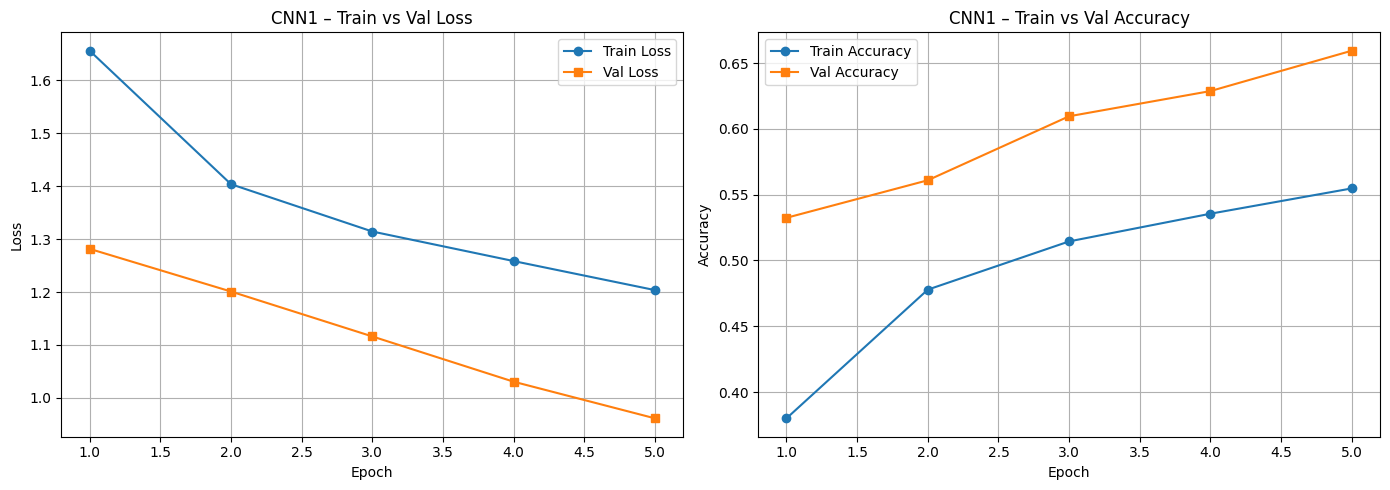

In [ ]:
print("Training CNN1...")
model1 = CNN1(accuracy_function=accuracy).to(device)
trainer = ModelTrainer()
start_time_avg = time.time()
history1 = trainer.fit(5, 0.001, model1, train_loader, val_loader,opt_func=torch.optim.Adam)
end_time_avg = time.time()
time_avg = end_time_avg - start_time_avg
print(f"Training time: {time_avg:.2f} seconds")
torch.save(model1.state_dict(), "/content/drive/MyDrive/CNN_models/CNN1.pth")
plot_history(history1, "CNN1")

Comment: I think its generalizing well, but it could benefit a lot from more epochs because right now the performance is not good and its kind of underfitting because it has only 2 layers and trained for only 5 epochs

Model 2


Training CNN2...
Epoch: 1 - Validation Loss: 1.0059, Validation Accuracy: 0.6322              
Epoch: 2 - Validation Loss: 0.9329, Validation Accuracy: 0.6641              
Epoch: 3 - Validation Loss: 0.7985, Validation Accuracy: 0.7135              
Epoch: 4 - Validation Loss: 0.8318, Validation Accuracy: 0.7191              
Epoch: 5 - Validation Loss: 0.6941, Validation Accuracy: 0.7561              
Training time (MaxPool): 1010.41 seconds


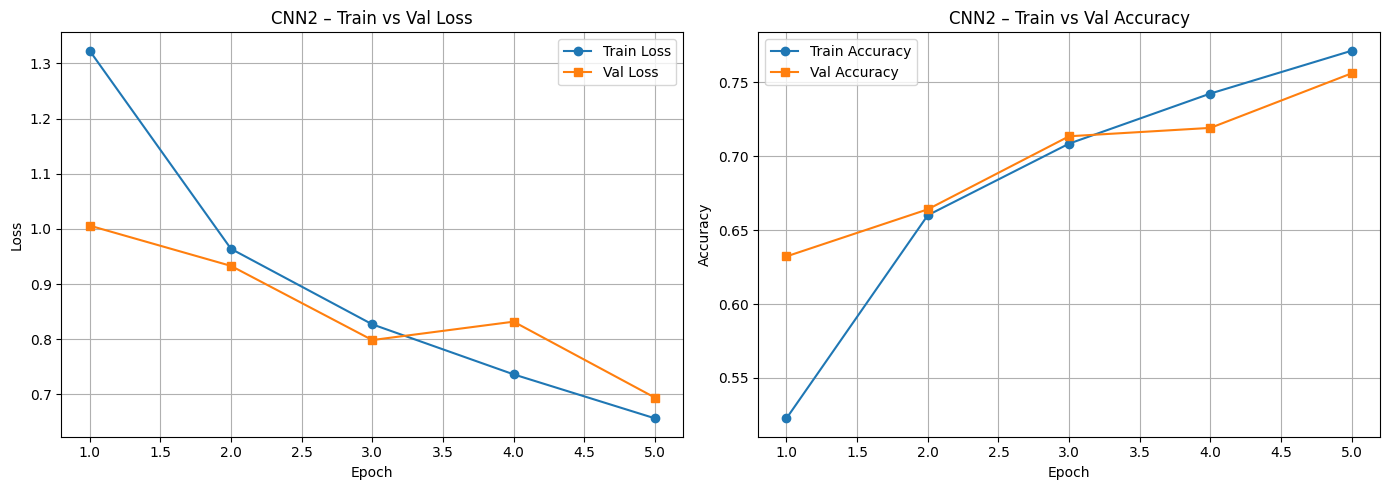

In [ ]:
print("\nTraining CNN2...")
model2 = CNN2(accuracy_function=accuracy).to(device)
trainer = ModelTrainer()
start_time_max = time.time()
history_max = trainer.fit(5, 0.001, model2, train_loader, val_loader,opt_func=torch.optim.Adam)
end_time_max = time.time()
time_max = end_time_max - start_time_max
print(f"Training time (MaxPool): {time_max:.2f} seconds")
torch.save(model2.state_dict(), "/content/drive/MyDrive/CNN_models/CNN2.pth")
plot_history(history_max,"CNN2")

Comment: Its generalizing well and since the curves are so close and even cross each other at some point meaning the model behaved almost identically on both the train and the validation data set at some point, there was a slight gap at the end between train and val loss but it narrowed down, and since the graphs are continuing to decrease i think more epochs would also improve the results  

Model 2 with Avgpooling


Training CNN2_avg...
Epoch: 1 - Validation Loss: 1.2317, Validation Accuracy: 0.5693              
Epoch: 2 - Validation Loss: 0.8398, Validation Accuracy: 0.6941              
Epoch: 3 - Validation Loss: 0.8182, Validation Accuracy: 0.7029              
Epoch: 4 - Validation Loss: 0.7646, Validation Accuracy: 0.7271              
Epoch: 5 - Validation Loss: 0.6987, Validation Accuracy: 0.7500              
Training time (AvgPool): 1000.48 seconds


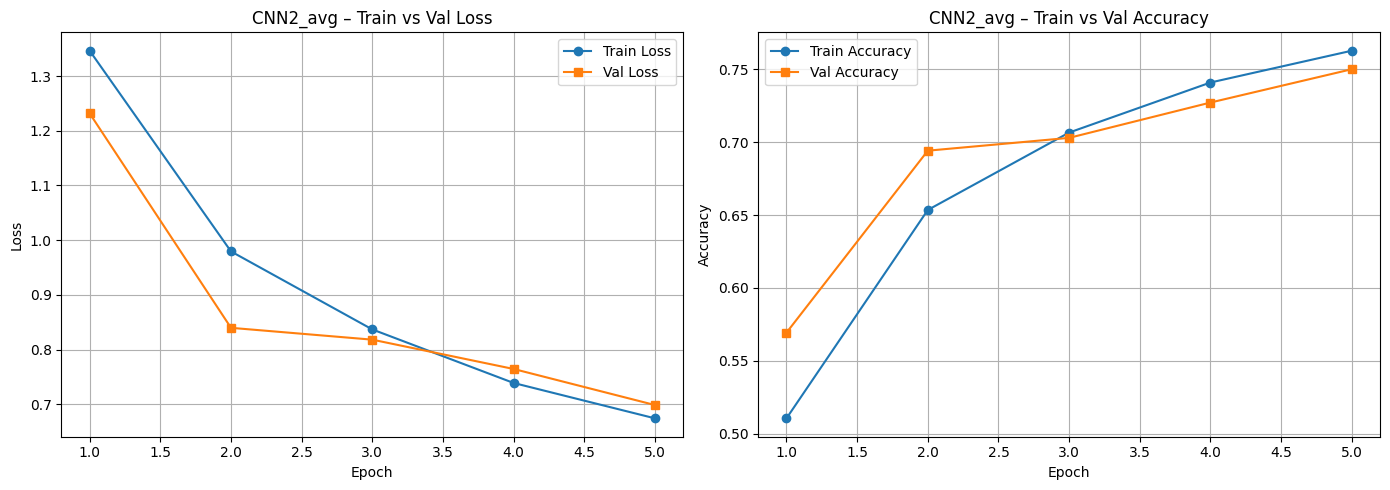

In [ ]:
print("\nTraining CNN2_avg...")
model2_avg = CNN2_avg(accuracy_function=accuracy).to(device)
trainer = ModelTrainer()
start_time_avg = time.time()
history_avg = trainer.fit(5, 0.001, model2_avg, train_loader, val_loader,opt_func=torch.optim.Adam)
end_time_avg = time.time()
time_avg = end_time_avg - start_time_avg
print(f"Training time (AvgPool): {time_avg:.2f} seconds")
torch.save(model2_avg.state_dict(), "/content/drive/MyDrive/CNN_models/CNN2avg.pth")
plot_history(history_avg,"CNN2_avg")

Comment: very similar behavior to that of maxpooling but here even the slight gap between the train and val loss is narrower showing better generalization even more than that of maxpooling (which is expected since it averages the features rather than letting one feature dominate)

# Graph Comparison between Maxpooling and Avgpooling



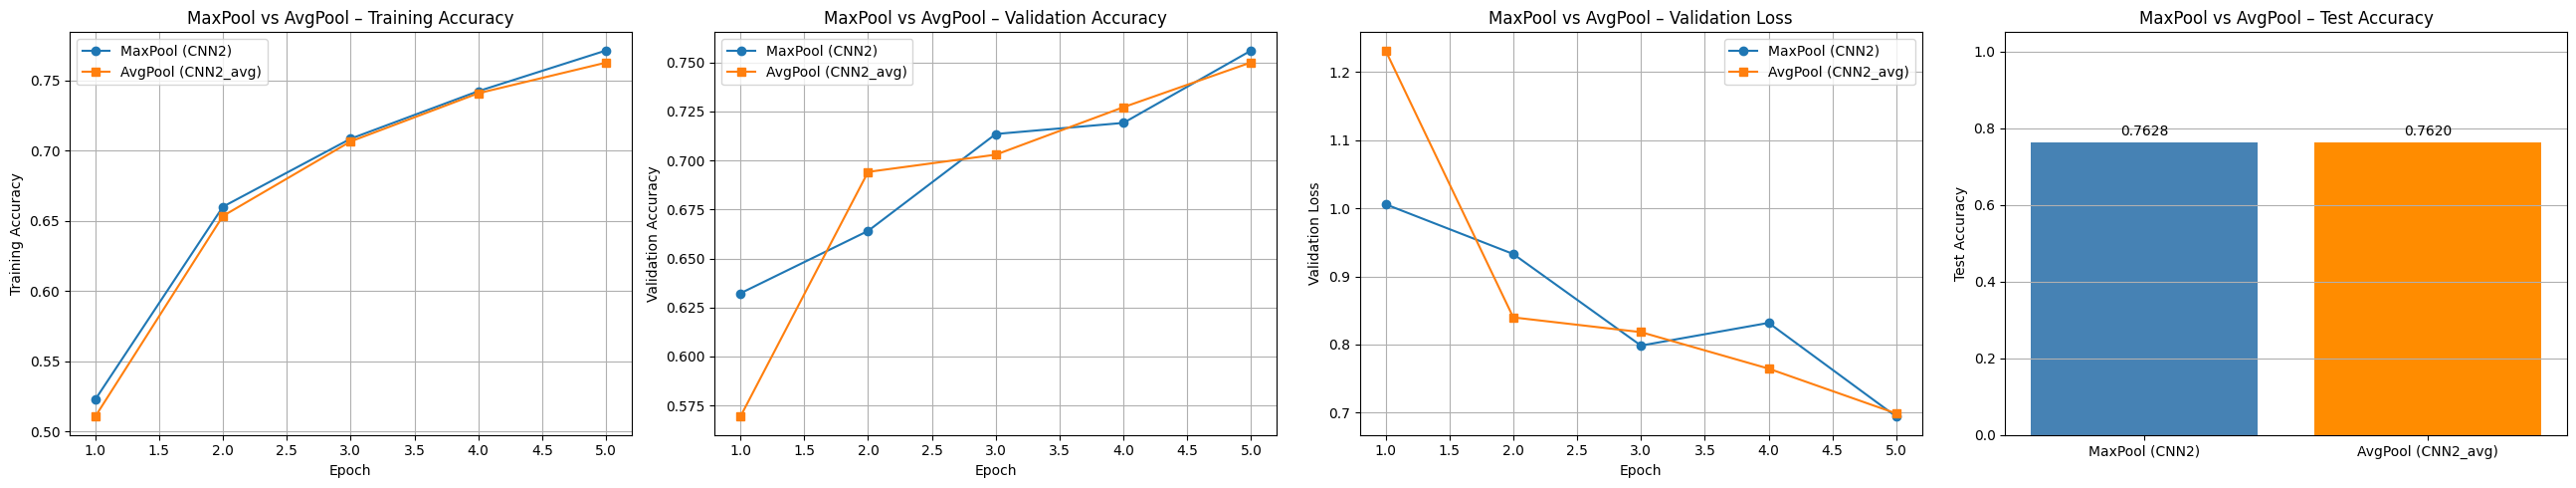


--- Pooling Comparison Summary ---
Model                        Train Acc     Test Acc      Val Acc    Training Time (s)
-------------------------------------------------------------------------------------
CNN2  (MaxPool)                 0.8234       0.7628       0.7561              1010.41
CNN2_avg (AvgPool)              0.8105       0.7620       0.7500              1000.48


In [ ]:
#the histories already stored in history_max (CNN2 MaxPool) and history_avg (CNN2_avg AvgPool)

#training & validation metrics
max_train_accs = [x['train_acc']  for x in history_max]
avg_train_accs = [x['train_acc']  for x in history_avg]
max_val_accs   = [x['val_acc']    for x in history_max]
avg_val_accs   = [x['val_acc']    for x in history_avg]
max_val_losses = [x['val_loss']   for x in history_max]
avg_val_losses = [x['val_loss']   for x in history_avg]

#Test accuracy
max_test_train_acc, max_test_acc = evaluate_model(model2,     train_loader, test_loader, device)
avg_test_train_acc, avg_test_acc = evaluate_model(model2_avg, train_loader, test_loader, device)

epochs = range(1, len(history_max) + 1)

fig, axes = plt.subplots(1, 4, figsize=(26, 5))

#Training Accuracy comparison
axes[0].plot(epochs, max_train_accs, '-o', label='MaxPool (CNN2)')
axes[0].plot(epochs, avg_train_accs, '-s', label='AvgPool (CNN2_avg)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Accuracy')
axes[0].set_title('MaxPool vs AvgPool – Training Accuracy')
axes[0].legend()
axes[0].grid(True)

#Validation Accuracy comparison
axes[1].plot(epochs, max_val_accs, '-o', label='MaxPool (CNN2)')
axes[1].plot(epochs, avg_val_accs, '-s', label='AvgPool (CNN2_avg)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('MaxPool vs AvgPool – Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

#Validation Loss comparison
axes[2].plot(epochs, max_val_losses, '-o', label='MaxPool (CNN2)')
axes[2].plot(epochs, avg_val_losses, '-s', label='AvgPool (CNN2_avg)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Validation Loss')
axes[2].set_title('MaxPool vs AvgPool – Validation Loss')
axes[2].legend()
axes[2].grid(True)

#Test Accuracy comparison (bar chart because based on the results of
#the separate model training, I knew the gap wouldn't be that big so
#i wanted to show that its tiny and that shows better on a bar graph)
test_accs  = [max_test_acc, avg_test_acc]
bar_labels = ['MaxPool (CNN2)', 'AvgPool (CNN2_avg)']
bars = axes[3].bar(bar_labels, test_accs, color=['steelblue', 'darkorange'])
axes[3].set_ylabel('Test Accuracy')
axes[3].set_title('MaxPool vs AvgPool – Test Accuracy')
axes[3].set_ylim(0, 1.05)
axes[3].grid(axis='y')
for bar in bars:
    axes[3].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#Summary table
print("\n--- Pooling Comparison Summary ---")
print(f"{'Model':<25} {'Train Acc':>12} {'Test Acc':>12} {'Val Acc':>12} {'Training Time (s)':>20}")
print("-" * 85)
print(f"{'CNN2  (MaxPool)':<25} {max_test_train_acc:>12.4f} {max_test_acc:>12.4f} {max_val_accs[-1]:>12.4f} {time_max:>20.2f}")
print(f"{'CNN2_avg (AvgPool)':<25} {avg_test_train_acc:>12.4f} {avg_test_acc:>12.4f} {avg_val_accs[-1]:>12.4f} {time_avg:>20.2f}")


### Comparison:

Maxpooling performed only a tiny bit better than Avgpooling in train,test and val accuracy (and also extra metric, but it had lower val loss) and thats because it takes the strongest feature and that makes it fit the data better and hence perform better. However, the gap between train acc and test acc for Maxpooling was bigger than that of Avgpooling meaning Avgpooling generalizes better (since it takes the average of all the features). Conclusion is that Maxpooling had better results but overall the two pooling methods resulted in similar performance

Model 3


Training CNN3...
Epoch: 1 - Validation Loss: 1.0960, Validation Accuracy: 0.6066              
Epoch: 2 - Validation Loss: 0.9425, Validation Accuracy: 0.6756              
Epoch: 3 - Validation Loss: 0.8472, Validation Accuracy: 0.7018              
Epoch: 4 - Validation Loss: 0.7993, Validation Accuracy: 0.7189              
Epoch: 5 - Validation Loss: 0.8874, Validation Accuracy: 0.7098              
Training time: 2129.71 seconds


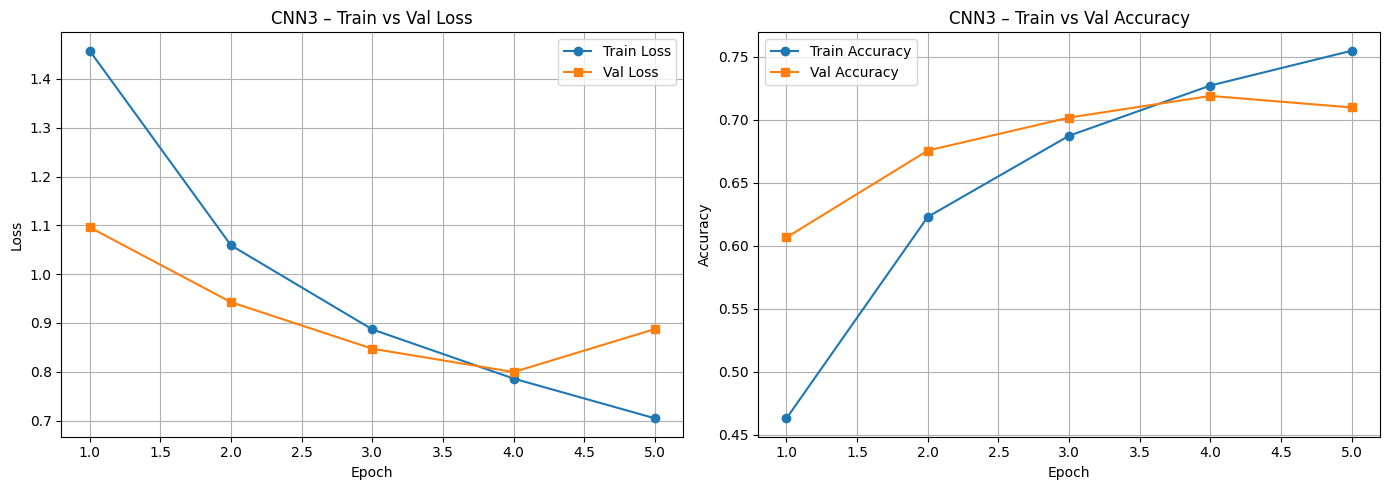

In [ ]:
print("\nTraining CNN3...")
model3 = CNN3(accuracy_function=accuracy).to(device)
trainer = ModelTrainer()
start_time_avg = time.time()
history3= trainer.fit(5, 0.001, model3, train_loader, val_loader,opt_func=torch.optim.Adam)
end_time_avg = time.time()
time_avg = end_time_avg - start_time_avg
print(f"Training time: {time_avg:.2f} seconds")
torch.save(model3.state_dict(), "/content/drive/MyDrive/CNN_models/CNN3.pth")
plot_history(history3, "CNN3")

Comment: Model shows good generalization since both the training and the validation accuracy (and loss) curves are close to each other and there are no increasing gaps so no overfitting

Model 4


Training CNN4...
Epoch: 1 - Validation Loss: 1.0751, Validation Accuracy: 0.6074              
Epoch: 2 - Validation Loss: 0.8499, Validation Accuracy: 0.6988              
Epoch: 3 - Validation Loss: 0.8201, Validation Accuracy: 0.7195              
Epoch: 4 - Validation Loss: 0.7287, Validation Accuracy: 0.7484              
Epoch: 5 - Validation Loss: 0.6056, Validation Accuracy: 0.7861              
Training time: 2425.87 seconds


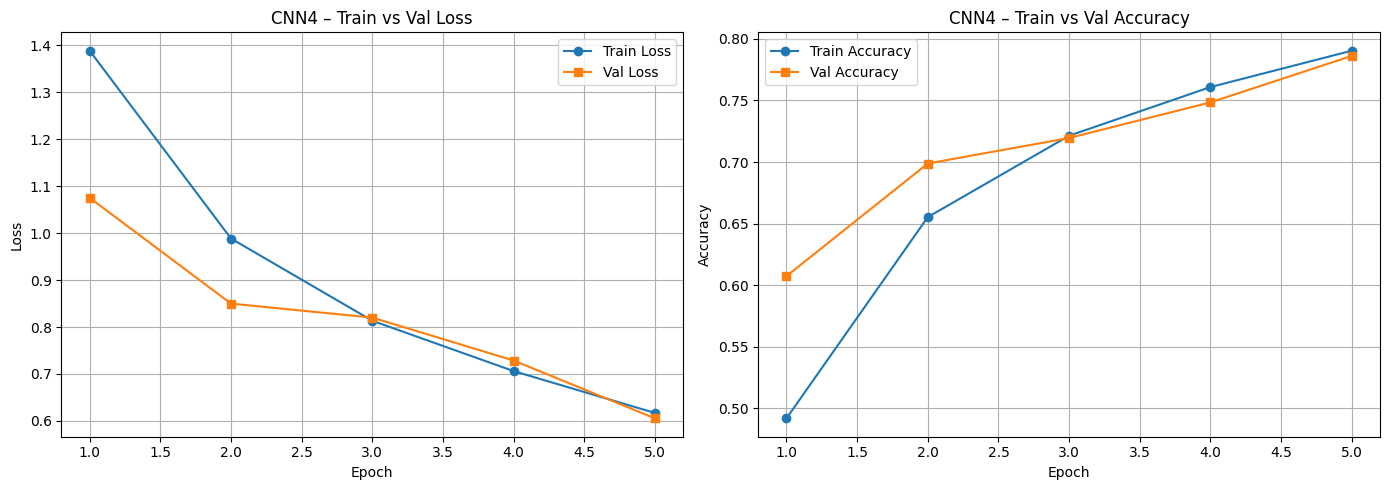

In [ ]:
print("\nTraining CNN4...")
model4 = CNN4(accuracy_function=accuracy).to(device)
trainer = ModelTrainer()
start_time_avg = time.time()
history4 = trainer.fit(5, 0.001, model4, train_loader, val_loader,opt_func=torch.optim.Adam)
end_time_avg = time.time()
time_avg = end_time_avg - start_time_avg
print(f"Training time: {time_avg:.2f} seconds")
torch.save(model4.state_dict(), "/content/drive/MyDrive/CNN_models/CNN4.pth")
plot_history(history4, "CNN4")

Comment:Its slightly overfitting since theres a gap between the val and train, this model is the deepest model so its expected to have some overfitting. Although val loss is lower at epoch 1 and val accuracy is higher than train accuracy that happens because dropout is on during training to prevent memorizing but off during validation and hence the model seems to be doing better on val at the start because its not regularized

# 7. Model Evaluation


Evaluating models... (this may take a moment)

Loading CNN1...
CNN1: Train Acc = 0.6973, Test Acc = 0.6699

Loading CNN2...
CNN2: Train Acc = 0.8234, Test Acc = 0.7628

Loading CNN3...
CNN3: Train Acc = 0.7608, Test Acc = 0.7188

Loading CNN4...
CNN4: Train Acc = 0.8371, Test Acc = 0.7930

Model          Train Accuracy    Test Accuracy       Gap
CNN1                   0.6973           0.6699    0.0274
CNN2                   0.8234           0.7628    0.0606
CNN3                   0.7608           0.7188    0.0420
CNN4                   0.8371           0.7930    0.0441


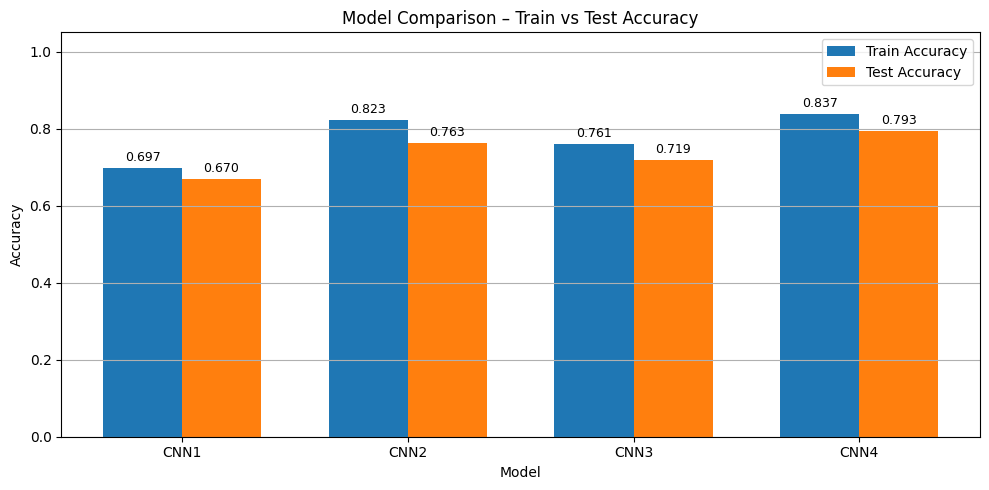

In [ ]:
results = {}

print("Evaluating models... (this may take a moment)")

#model names to (path, class)
model_info = {
    "CNN1": ("/content/drive/MyDrive/CNN_models/CNN1.pth", CNN1),
    "CNN2": ("/content/drive/MyDrive/CNN_models/CNN2.pth", CNN2),
    "CNN3": ("/content/drive/MyDrive/CNN_models/CNN3.pth", CNN3),
    "CNN4": ("/content/drive/MyDrive/CNN_models/CNN4.pth", CNN4),
}

for name, (path, ModelClass) in model_info.items():
    print(f"\nLoading {name}...")

    #Recreate model architecture
    model = ModelClass(accuracy_function=accuracy).to(device)

    #Load saved weights
    model.load_state_dict(torch.load(path, map_location=device))

    #Evaluate
    tr_acc, te_acc = evaluate_model(model, train_loader, test_loader, device)
    results[name] = {'train_acc': tr_acc, 'test_acc': te_acc}

    print(f"{name}: Train Acc = {tr_acc:.4f}, Test Acc = {te_acc:.4f}")

    #to free memory
    del model
    torch.cuda.empty_cache()


# Comparison table
print("\n" + "=" * 55)
print(f"{'Model':<12} {'Train Accuracy':>16} {'Test Accuracy':>16} {'Gap':>9}")
print("=" * 55)
for name, r in results.items():
    gap = r['train_acc'] - r['test_acc']
    print(f"{name:<12} {r['train_acc']:>16.4f} {r['test_acc']:>16.4f} {gap:>9.4f}")
print("=" * 55)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
model_names = list(results.keys())
train_accs  = [results[m]['train_acc'] for m in model_names]
test_accs   = [results[m]['test_acc']  for m in model_names]

x      = range(len(model_names))
width  = 0.35

bars1 = ax.bar([i - width/2 for i in x], train_accs, width, label='Train Accuracy')
bars2 = ax.bar([i + width/2 for i in x], test_accs,  width, label='Test Accuracy')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison – Train vs Test Accuracy')
ax.set_xticks(list(x))
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

note: I did not include CNN_2 avgpooling version in the final comparison since its the same exact architecture as CNN 2 but only difference is the pooling technique and the comparison between the two (on train and test sets) is in the above cells

# 8. Hyperparameter Tuning  


tuning CNN2 because its not too small and not too large



--- Experiment: LR=0.001 (base) ---
Epoch: 1 - Validation Loss: 1.7570, Validation Accuracy: 0.4137              
Epoch: 2 - Validation Loss: 1.5338, Validation Accuracy: 0.4752              
Epoch: 3 - Validation Loss: 1.3971, Validation Accuracy: 0.5121              
Epoch: 4 - Validation Loss: 1.3154, Validation Accuracy: 0.5412              
Epoch: 5 - Validation Loss: 1.2493, Validation Accuracy: 0.5598              
Epoch: 6 - Validation Loss: 1.1847, Validation Accuracy: 0.5844              
Epoch: 7 - Validation Loss: 1.1498, Validation Accuracy: 0.5896              
Epoch: 8 - Validation Loss: 1.1043, Validation Accuracy: 0.6078              
Final Val Acc: 0.6078

--- Experiment: LR=0.0001 ---
Epoch: 1 - Validation Loss: 2.1794, Validation Accuracy: 0.2469              
Epoch: 2 - Validation Loss: 2.0833, Validation Accuracy: 0.3072              
Epoch: 3 - Validation Loss: 2.0071, Validation Accuracy: 0.3402              
Epoch: 4 - Validation Loss: 1.9356, Validation Accur

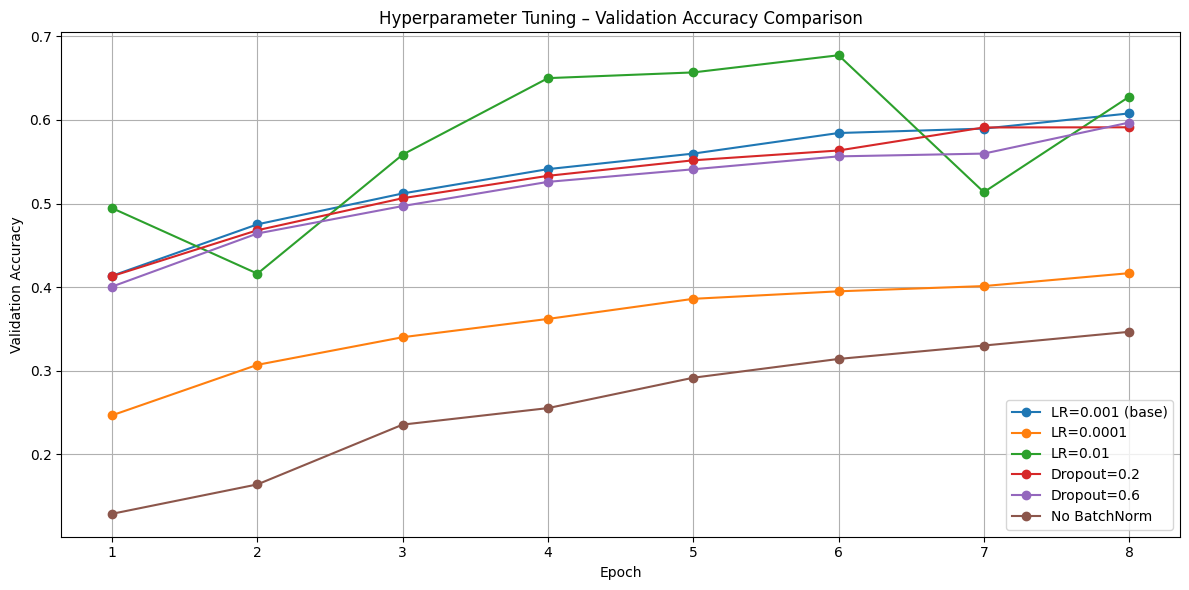

In [ ]:
class CNN2_tunable(nn.Module):
    def __init__(self, accuracy_function, dropout_rate=0.4, use_batchnorm=True):
        super().__init__()
        self.accuracy_function = accuracy_function

        def conv_block(in_ch, out_ch):
            layers = [nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1)]
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_ch))   #batchnorm helps keep the values from getting too large to prevent unstable training
            layers += [nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2)]
            return layers

        self.model = nn.Sequential(
            #Dimension: 32x32 to 16x16
            *conv_block(3, 64),#we use the star to unpack the conv block so at the end its like the normal sequence of layers
            #Dimension: 16x16 to 8x8
            *conv_block(64, 128),
            #Dimension: 8x8 to 4x4
            *conv_block(128, 128),
            #NN itself
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),   #randomly zeroing out neurons to reduce overfitting
            nn.Linear(256, 10)
        )

    def forward(self, input_image):
        output = self.model(input_image)
        return output

    def training_step(self, batch):
        images, labels = batch
        images = images.to(device=device)
        labels = labels.to(device=device)
        output = self(images)
        loss = F.cross_entropy(output, labels)
        acc  = self.accuracy_function(output, labels)
        return {'training_loss': loss, 'training_acc': acc}

    def validation_step(self, batch):
        images, labels = batch
        images = images.to(device=device)
        labels = labels.to(device=device)
        output = self(images)
        loss = F.cross_entropy(output, labels)
        acc  = self.accuracy_function(output, labels)
        return {'val_loss': loss, 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss   = torch.stack(batch_losses).mean()
        batch_accs   = [x['val_acc'] for x in outputs]
        epoch_acc    = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch: {} - Validation Loss: {:.4f}, Validation Accuracy: {:.4f}\
              ".format(
              epoch+1, result['val_loss'], result['val_acc']))

#configurations
experiments = [
    #(label,lr,dropout, batchnorm)
    ("LR=0.001 (base)",  0.001,   0.4,     True),
    ("LR=0.0001",        0.0001,  0.4,     True),
    ("LR=0.01",          0.01,    0.4,     True),
    ("Dropout=0.2",      0.001,   0.2,     True),
    ("Dropout=0.6",      0.001,   0.6,     True),
    ("No BatchNorm",     0.001,   0.4,     False),
]

exp_trainer  = ModelTrainer()
exp_results  = {}

for label, lr, dropout, use_bn in experiments:
    print(f"\n--- Experiment: {label} ---")
    model_exp = CNN2_tunable(accuracy_function=accuracy,
                             dropout_rate=dropout,
                             use_batchnorm=use_bn).to(device)
    hist = exp_trainer.fit(8, lr, model_exp, train_loader, val_loader)
    exp_results[label] = hist
    print(f"Final Val Acc: {hist[-1]['val_acc']:.4f}")

#Summary comparison
print("\n" + "=" * 70)
print(f"{'Experiment':<22} {'Final Train Acc':>17} {'Final Val Acc':>15} {'Best Val Acc':>14}")
print("=" * 70)
for label, hist in exp_results.items():
    final_tr  = hist[-1]['train_acc']
    final_val = hist[-1]['val_acc']
    best_val  = max(x['val_acc'] for x in hist)
    print(f"{label:<22} {final_tr:>17.4f} {final_val:>15.4f} {best_val:>14.4f}")
print("=" * 70)

#val accuracy across epochs for all experiments
plt.figure(figsize=(12, 6))
for label, hist in exp_results.items():
    val_accs = [x['val_acc'] for x in hist]
    plt.plot(range(1, len(hist)+1), val_accs, '-o', label=label)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Hyperparameter Tuning – Validation Accuracy Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Comment:

**Learning Rate:**

LR=0.0001 was too little so the model barely reached 41% after 8 epochs because the weight updates are so tiny it needs many more epochs to converge.

LR=0.001 was stable and consistent snd loss decreased smoothly every epoch and reached 60.7%.

LR=0.01 was the best performer (67.7% best val acc) but unstable as there was a spike at epoch 7 where val loss went from 0.91 to 1.73 and accuracy dropped from 67% to 51% thats because the learning rate is too large and is overshooting the minimum

**Dropout:**

Dropout=0.2 (low regularization) performed a bit worse than the original 0.4 and resulted in 59.1%,because it drops fewer neurons, the model is less regularized and is more prone to overfitting.

Dropout=0.6 (more regularization) also performed a bit worse and is at 59.7%. It drops a lot more neurons (60%) losing too much information during training so it has slower learning.

The original Dropout=0.4 was the best for this architecture.

**Batch Normalization:**

No BatchNorm was the worst result with only 34.7% after 8 epochs this shows why BatchNorm matters because without it, activations get unstable and the model finds it difficult to learn.



# Future Work

I would suggest that for future work I could use more layer variations with different dropouts so I can observe how the behavior changes through the different architectures more clearly. I learnt that from this assignment with the hyperparamter runing part so far, but I wanted to try more variations and architectures but I was limited to the runtime and resources of colab.I think I would also want to automate the model training process to loop over all the models and train them all at once introducing a sense of automated workflow, but again what stopped me was the runtime limit. For this specific assignment I would want to train my models for more epochs because my models showed improving accuracy and loss curves which indicate that if I jad trained them a bit more I couldve reached even better accuracy, use data augmentation to make my models more robust (but I think that was outside the scope of this assignment, will definitely use it in the project though (isA) ) and finally I would add a learning rate scheduler to try and make the most of the architecture with decaying learning rates as the epochs progress (I tested lr decay with modle 4 and it got 79%)

###  Reflection Question

Answer the following questions in the Markdown cell below:

1. What do you observe in the learned filters? Can you identify any patterns (e.g., edge detectors, color detectors)?
2. How does **Max Pooling** differ from **Average Pooling**? When might you prefer one over the other?
3. If you increase the number of filters in a conv layer, how does that affect the number of trainable parameters?

**Your Answer:**

1. Filters early on work directly on pixels so they learn features like edges (edge detectors) in different positions and also learn colors (color detectors).
In a further layer like layer 2 filters dont work on pixels they work on feature maps from the layer before. So they learn combinations of the previously learnt features producing some level of patterns like corners and simple shapes.
Even further filters in further layers learn the hardest and most complex combinations of textures and shapes that  actually differentiate between classes.
Theres an analogy we took in class that in facial detection the first layers learn the low level features of the face, mouth, eyes etc and then the next layers learn to put each feature together on it own (mouth on its own,eye on its own) then the last layers learn to put the whole face together

2. Maxpooling takes the largest value (max)every time the filter is applied on the picture, this keeps the most strong feature and puts it in the pixel of the new image. Avgpooling however takes the average of all the values in that filter application so the strength of all the pixels is averaged and not one strong feature dominates. We use maxpooling when we want to strong and unique features like edges for example and when we want to know if a feature exists. Avgpooling is used when we want a general idea about the distribution of the features and its less sensitive to noise (since it averages and doesnt take the strongest feature, so its not affected by noise as much) and hence produces smoother interpretations not affected my tiny changes like lighting for example.

3. As we increase the number of filters the number of trainable parameters increases because each filter acts as a feature detector so the more filters the more features learned, hence the more trainable parameters (my models had millions of parameters thats why they took ages to run)